In [ ]:
import tensorflow_datasets as tfds

In [ ]:
import tensorflow as tf 
tf.compat.v1.disable_eager_execution()
import numpy as np 
import matplotlib.pyplot as plt 

# Dataset

In [ ]:
import pathlib

train_path = pathlib.Path('dataset/train')
#valid_path = pathlib.Path('dataset/valid')
test_path = pathlib.Path('dataset/test')

In [ ]:
img_height = 224
img_width = 224

train_ds = tf.keras.utils.image_dataset_from_directory(
  train_path,
  label_mode='categorical',
  color_mode='grayscale',
  validation_split=None,
  subset=None,
  seed=None,
  batch_size=None,
  image_size=(img_height, img_width))

test_ds = tf.keras.utils.image_dataset_from_directory(
  test_path,
  label_mode='categorical',
  color_mode='grayscale',
  validation_split=None,
  subset=None,
  seed=None,
  batch_size=None,
  image_size=(img_height, img_width))



Found 13572 files belonging to 100 classes.
Found 500 files belonging to 100 classes.


In [ ]:
# From Tensorflow dataset to numpy array
train_np=tfds.as_numpy(train_ds)

train_dict = {}

for i,ex in enumerate(train_np):
  train_dict[str(i)] =ex

x_train=[]
y_train=[]

for j, ex in enumerate(train_dict):
    x_train.append(np.reshape(train_dict[str(j)][0],(224*224)))
    y_train.append(train_dict[str(j)][1])

    
test_np=tfds.as_numpy(test_ds)

test_dict = {}

for i,ex in enumerate(test_np):
  test_dict[str(i)] =ex

x_test=[]
y_test=[]

for j, ex in enumerate(test_dict):
    x_test.append(np.reshape(test_dict[str(j)][0],(224*224)))
    y_test.append(test_dict[str(j)][1])

In [ ]:
x_train, y_train, x_test, y_test= np.array(x_train),np.array(y_train), np.array(x_test), np.array(y_test)

In [ ]:
#Scaling down between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
x_train.shape, y_train.shape

((13572, 50176), (13572, 100))

# Hyperparameters

In [ ]:
num_features =50176  # 224*224
num_labels = 100
learning_rate = 0.0001
batch_size = 32
training_epochs = 20
display_step = 1

# Model

In [ ]:
x = tf.compat.v1.placeholder(tf.float32, shape=[None, num_features])
y = tf.compat.v1.placeholder(tf.float32, shape=[None, num_labels])

In [ ]:
# Weight
W = tf.Variable(tf.zeros([num_features, num_labels]))

# Bias
b = tf.Variable(tf.zeros([num_labels]))

In [ ]:

# Construct model
pred = tf.nn.softmax(tf.matmul(x, W) + b) # Softmax

# Minimize error using cross entropy
cost = tf.compat.v1.reduce_mean(-tf.compat.v1.reduce_sum(y*tf.math.log(pred), reduction_indices=1))

# Gradient Descent
optimizer = tf.compat.v1.train.GradientDescentOptimizer(learning_rate).minimize(cost)

In [ ]:
# Initialize the variables (i.e. assign their default value)
init = tf.compat.v1.global_variables_initializer()

In [ ]:
def accuracy(predictions, labels): 
    correctly_predicted = np.sum(np.argmax(predictions, 1) == np.argmax(labels, 1)) 
    acc = (100.0 * correctly_predicted) / predictions.shape[0] 
    return acc

In [ ]:
with tf.compat.v1.Session() as sess:

    # Run the initializer
    sess.run(init)
    
    #Accuracy and Cost storage
    train_cost=[]
    train_acc=[]
    test_cost=[]
    test_acc=[]
    
    # Training cycle
    for epoch in range(training_epochs):
        train_cost.append(avg_cost)
        train_acc.append(avg_acc)
        
        avg_cost = 0.0
        avg_acc = 0.0
        total_batch = len(x_train)//batch_size
        
        
        for i in range(total_batch):
            batch_x = x_train[i:i+1*batch_size]
            batch_y = y_train[i:i+1*batch_size]
            
            _, c = sess.run([optimizer, cost], feed_dict={x: batch_x, y: batch_y})
            avg_cost += c/total_batch
            
            pred_y = sess.run(pred, feed_dict={x: batch_x})
            acc = accuracy(pred_y, batch_y)
            avg_acc += acc/total_batch
            
            
        if (epoch+1) % display_step == 0:
            tc = sess.run(cost, feed_dict={x: x_test, y: y_test})
            test_cost.append(tc)
            pred_y = sess.run(pred, feed_dict={x: x_test})
            ta = accuracy(pred_y, y_test)
            test_acc.append(ta)
            
            print("Epoch: {:2.0f} - Cost: {:1.5f} - Acc: {:0.5f} - Test Cost: {:0.5f} - Test Acc: {:0.5f}".format(
                epoch+1, avg_cost, avg_acc, tc, ta))
            
    print("Optimization Finshed")
    
    # Test model
    correct_prediction = tf.equal(tf.argmax(pred, 1), tf.argmax(y, 1))
    # Calculate accuracy
    acc = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))
    print("Test Accuracy:", acc.eval({x: x_test, y: y_test}))

Epoch:  1 - Cost: 4.18581 - Acc: 8.82223 - Test Cost: 4.77987 - Test Acc: 1.60000
Epoch:  2 - Cost: 3.90600 - Acc: 18.04245 - Test Cost: 4.77009 - Test Acc: 2.40000
Epoch:  3 - Cost: 3.64850 - Acc: 27.69015 - Test Cost: 4.75432 - Test Acc: 3.40000
Epoch:  4 - Cost: 3.41368 - Acc: 37.57370 - Test Cost: 4.74083 - Test Acc: 3.40000
Epoch:  5 - Cost: 3.19766 - Acc: 46.35908 - Test Cost: 4.72995 - Test Acc: 3.60000
Epoch:  6 - Cost: 2.99796 - Acc: 55.04127 - Test Cost: 4.72129 - Test Acc: 4.00000
Epoch:  7 - Cost: 2.81287 - Acc: 62.66215 - Test Cost: 4.71444 - Test Acc: 4.00000
Epoch:  8 - Cost: 2.64114 - Acc: 68.69841 - Test Cost: 4.70905 - Test Acc: 4.00000
Epoch:  9 - Cost: 2.48175 - Acc: 73.51857 - Test Cost: 4.70490 - Test Acc: 3.80000
Epoch: 10 - Cost: 2.33382 - Acc: 76.91627 - Test Cost: 4.70180 - Test Acc: 4.00000
Epoch: 11 - Cost: 2.19653 - Acc: 80.04864 - Test Cost: 4.69964 - Test Acc: 4.00000
Epoch: 12 - Cost: 2.06912 - Acc: 82.42925 - Test Cost: 4.69832 - Test Acc: 4.20000
Epoch

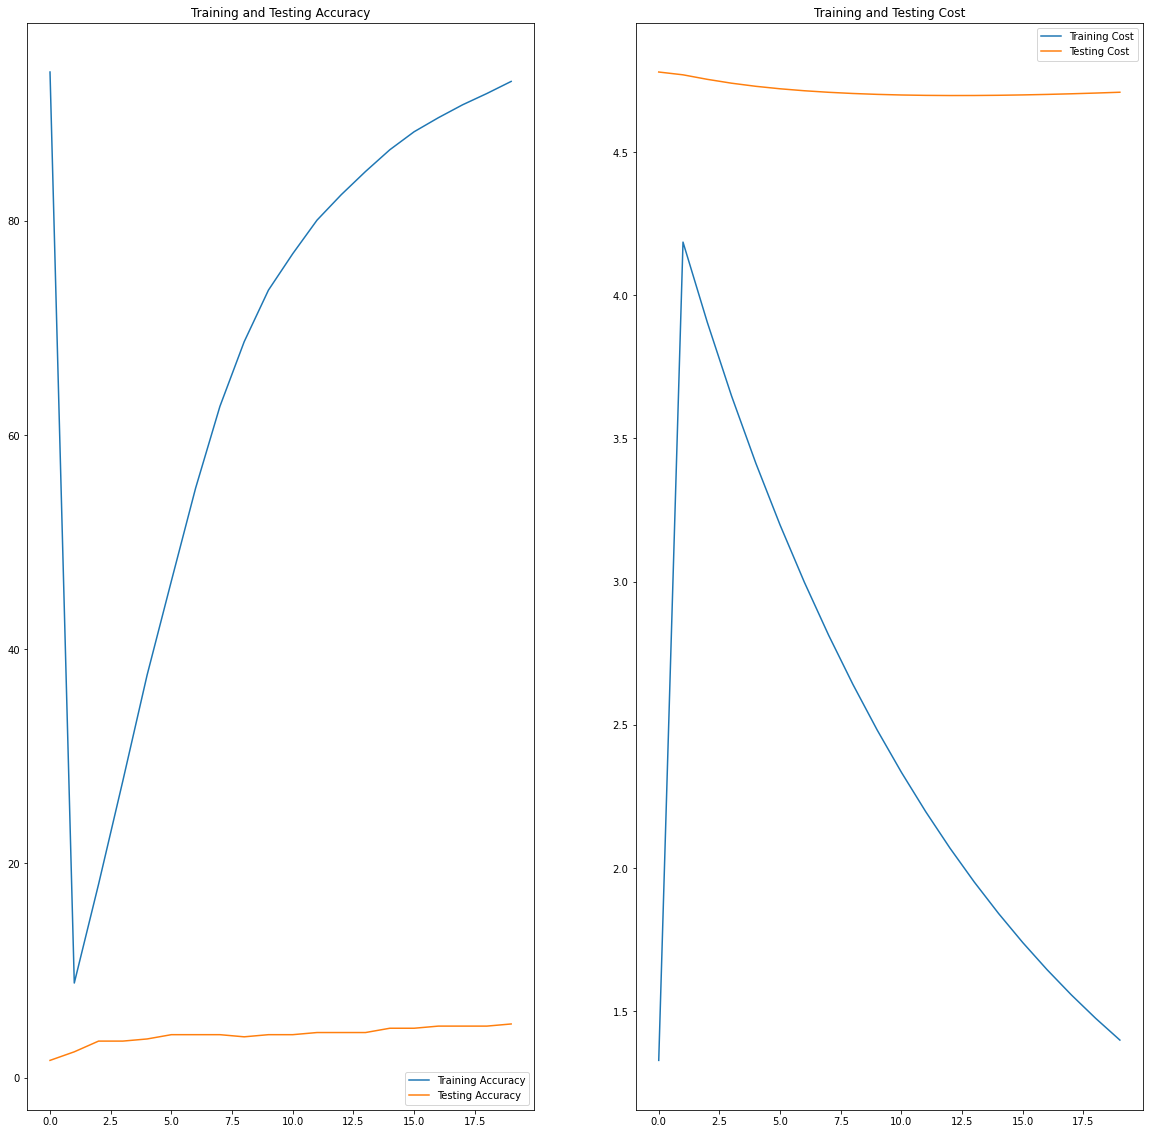

In [ ]:
epochs_range = range(training_epochs)

plt.figure(figsize=(20, 20))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, test_acc, label='Testing Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Testing Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_cost, label='Training Cost')
plt.plot(epochs_range, test_cost, label='Testing Cost')
plt.legend(loc='upper right')
plt.title('Training and Testing Cost')
plt.show()
